# Untouched Test And Paired Hypothesis Tests

The champion is locked using the selection window before the final twelve origins are scored. Paired t and Wilcoxon tests compare material-month absolute errors. A DM-style test uses twelve monthly aggregate loss differentials and is explicitly treated as low-power evidence.


In [1]:
from pathlib import Path
import json
import pandas as pd
try:
    from IPython.display import Image, display
except ImportError:
    class Image:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return f"Image({self.filename})"
    def display(value): print(value)

ROOT = Path.cwd()
if ROOT.name != "v8_controlled_synthetic_validation":
    candidate = ROOT / "Ai miroservices/modeling/v8_controlled_synthetic_validation"
    ROOT = candidate if candidate.exists() else ROOT
OUT = ROOT / "outputs"
DATA = OUT / "data"
PLOTS = OUT / "plots"
EVAL = OUT / "evaluator"
summary = json.loads((OUT / "run_summary.json").read_text())


In [2]:
leaderboard = pd.read_csv(OUT / "model_leaderboard.csv")
leaderboard.assign(WAPE_pct=100*leaderboard.WAPE, Bias_pct=100*leaderboard.Bias, shock_WAPE_pct=100*leaderboard.shock_WAPE).round(2)


,model,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate,shock_WAPE,WAPE_pct,Bias_pct,shock_WAPE_pct
0,random_forest_causal,1440,120,0.08,728.12,1368.40,0.01,0.47,0.08,8.24,0.70,8.08
1,extra_trees_causal,1440,120,0.08,736.76,1408.46,-0.00,0.48,0.09,8.34,-0.15,8.57
2,bom_plan,1440,120,0.09,752.43,1347.60,0.02,0.42,0.08,8.51,1.84,8.31
3,lightgbm_causal_tweedie,1440,120,0.09,762.68,1530.02,-0.01,0.51,0.09,8.63,-0.72,8.69
4,lightgbm_causal_ratio,1440,120,0.09,809.94,1541.10,0.00,0.49,0.09,9.16,0.20,8.79
5,lightgbm_direct_ratio,1440,120,0.10,910.64,1662.40,0.00,0.48,0.10,10.30,0.12,9.77
6,holt_damped,1440,120,0.11,944.07,1798.70,-0.01,0.53,0.11,10.68,-1.21,10.54
7,seasonal_naive,1440,120,0.14,1203.55,2222.65,-0.06,0.62,0.17,13.62,-5.88,17.35
8,croston_sba,1440,120,0.15,1318.09,2583.60,-0.10,0.68,0.17,14.91,-9.65,16.63
9,moving_average_6,1440,120,0.15,1363.65,2519.72,-0.01,0.51,0.13,15.43,-1.24,12.86


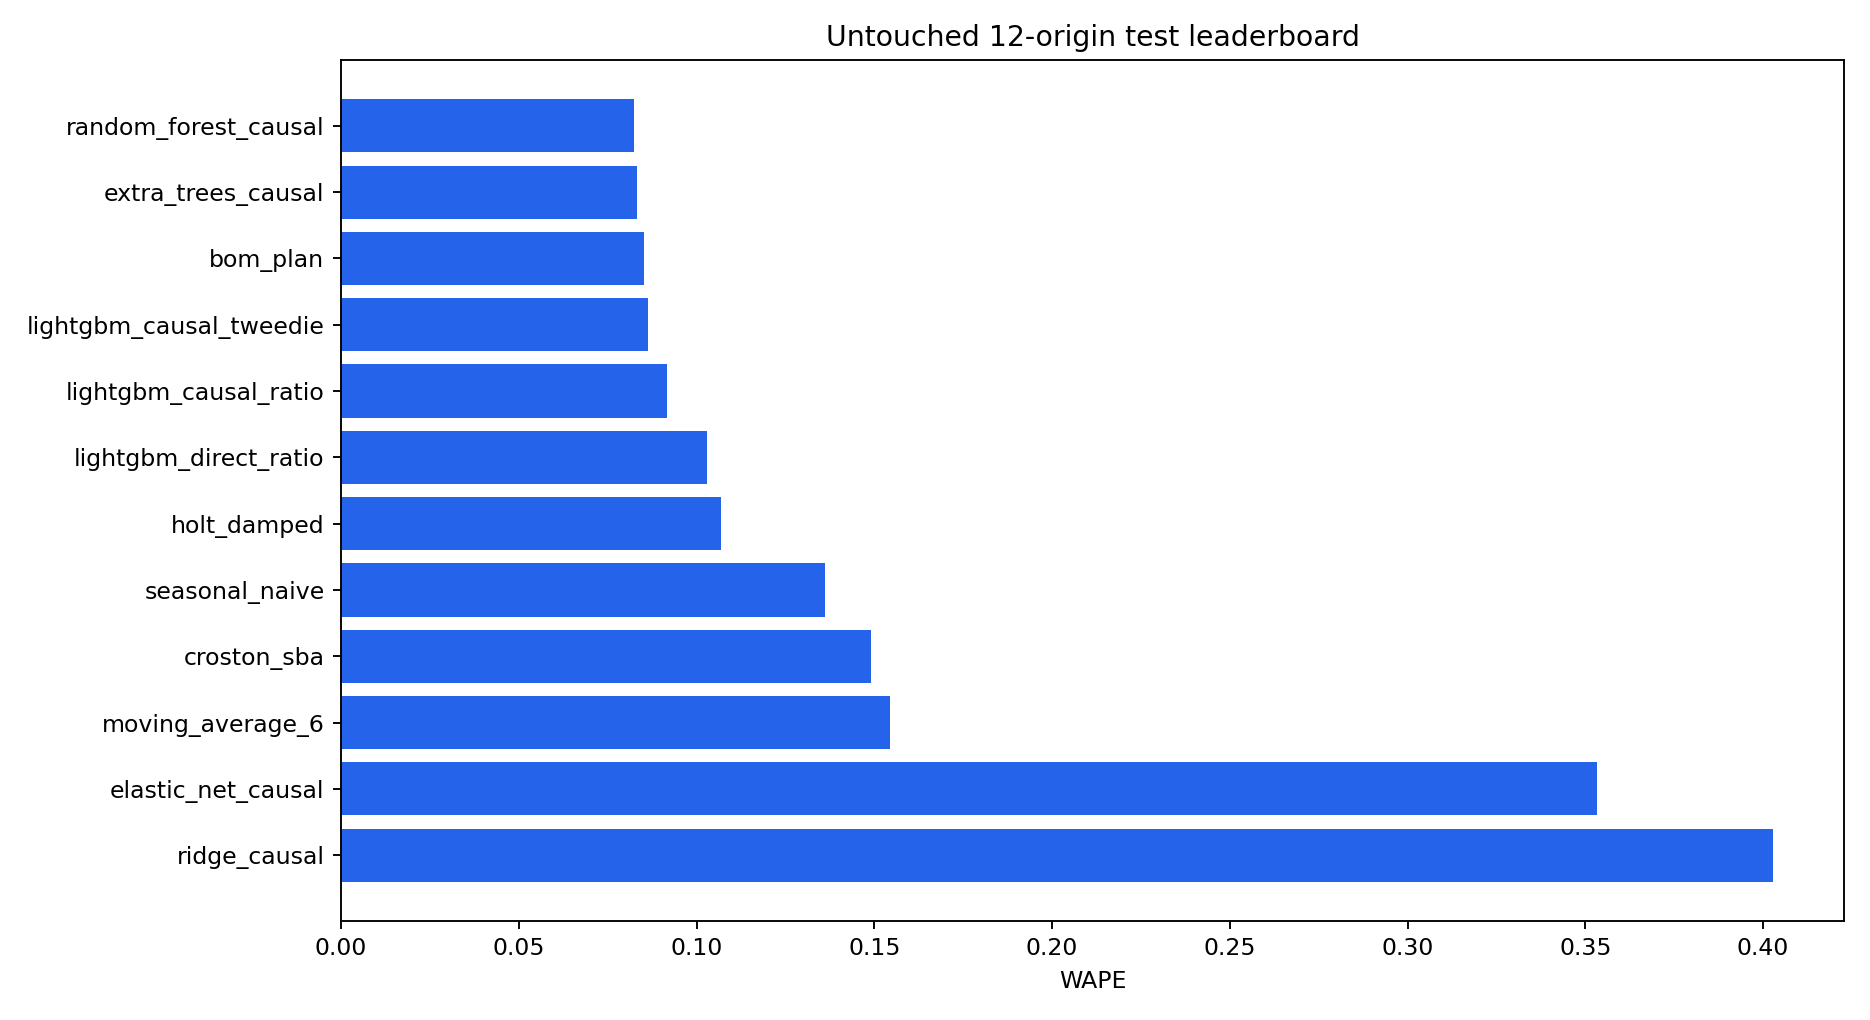

In [3]:
display(Image(filename=str(PLOTS / '02_model_leaderboard.png')))


In [4]:
tests = pd.read_csv(OUT / "paired_model_tests.csv")
tests.round({"mean_abs_error_delta": 2, "paired_t_p_value": 4, "wilcoxon_p_value": 4, "monthly_dm_style_p_value": 4})


,champion,candidate,paired_rows,mean_abs_error_delta,paired_t_statistic,paired_t_p_value,wilcoxon_statistic,wilcoxon_p_value,monthly_dm_style_statistic,monthly_dm_style_p_value,test_limit
0,extra_trees_causal,ridge_causal,1440,-2822.93,-4.674358,0.0000,241310.0,0.0000,-7.622157,0.0000,DM-style test uses 12 monthly aggregate loss d...
1,extra_trees_causal,elastic_net_causal,1440,-2384.75,-4.702907,0.0000,278456.0,0.0000,-7.275261,0.0000,DM-style test uses 12 monthly aggregate loss d...
2,extra_trees_causal,moving_average_6,1440,-626.89,-16.060930,0.0000,211790.0,0.0000,-6.475788,0.0000,DM-style test uses 12 monthly aggregate loss d...
3,extra_trees_causal,croston_sba,1440,-581.33,-13.569209,0.0000,253179.0,0.0000,-4.733303,0.0006,DM-style test uses 12 monthly aggregate loss d...
4,extra_trees_causal,seasonal_naive,1440,-466.79,-13.810919,0.0000,249676.0,0.0000,-6.482011,0.0000,DM-style test uses 12 monthly aggregate loss d...
5,extra_trees_causal,holt_damped,1440,-207.31,-9.192462,0.0000,339649.0,0.0000,-8.535758,0.0000,DM-style test uses 12 monthly aggregate loss d...
6,extra_trees_causal,lightgbm_direct_ratio,1440,-173.88,-8.662011,0.0000,348171.0,0.0000,-6.828882,0.0000,DM-style test uses 12 monthly aggregate loss d...
7,extra_trees_causal,lightgbm_causal_ratio,1440,-73.19,-4.415730,0.0000,432189.0,0.0000,-4.372356,0.0011,DM-style test uses 12 monthly aggregate loss d...
8,extra_trees_causal,lightgbm_causal_tweedie,1440,-25.92,-1.492520,0.1358,507894.0,0.4912,-0.991559,0.3427,DM-style test uses 12 monthly aggregate loss d...
9,extra_trees_causal,bom_plan,1440,-15.68,-0.909248,0.3634,460684.0,0.0002,-0.487089,0.6358,DM-style test uses 12 monthly aggregate loss d...


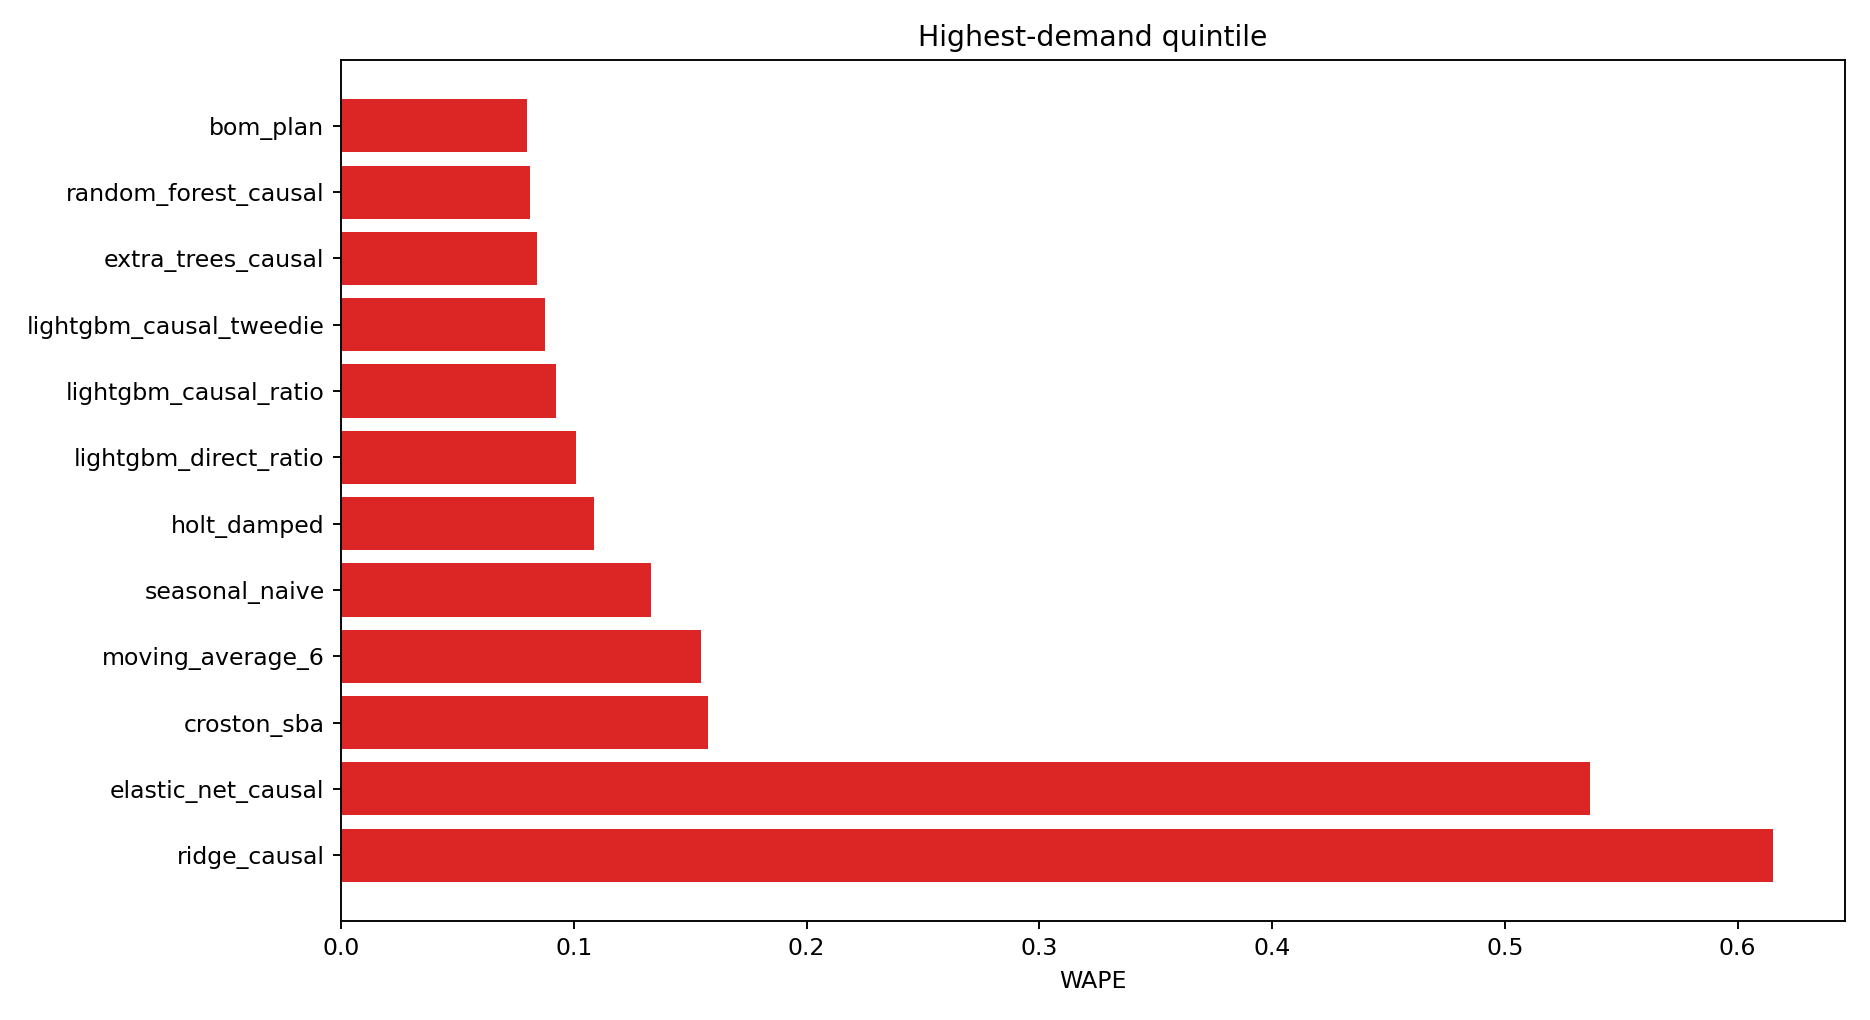

In [5]:
display(Image(filename=str(PLOTS / '04_high_volume_comparison.png')))


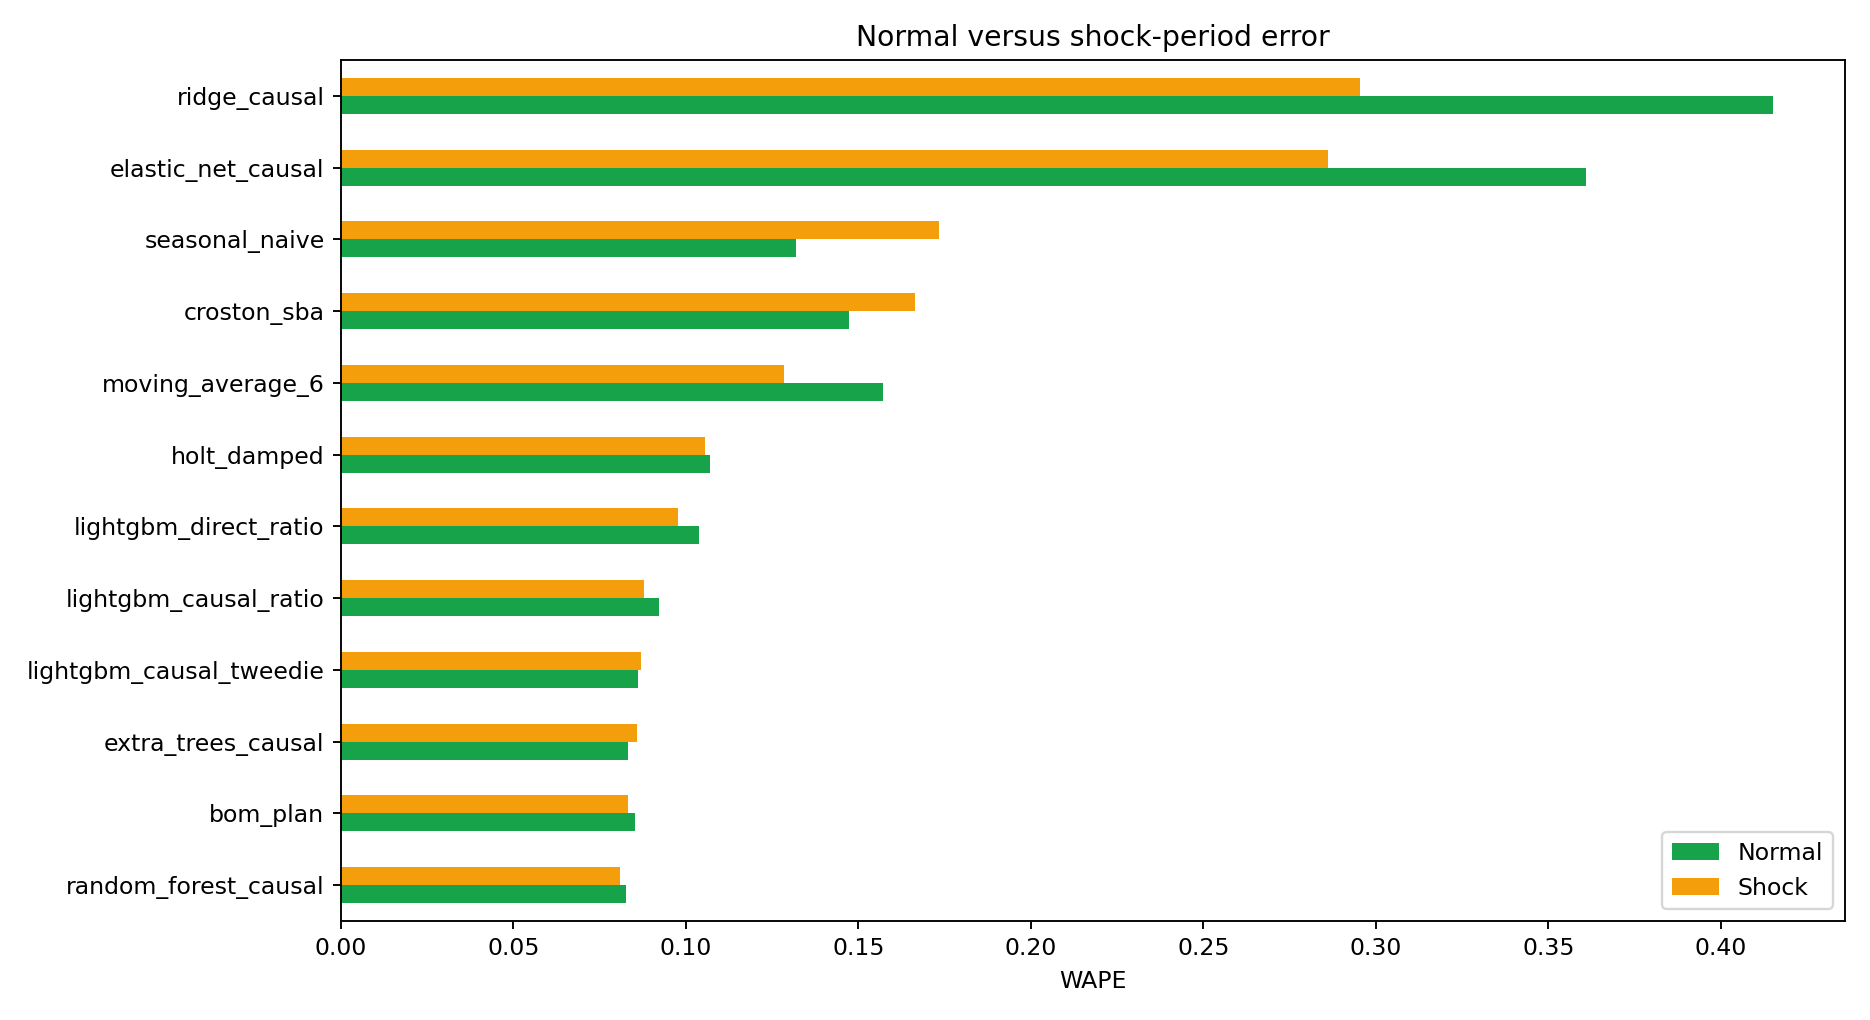

In [6]:
display(Image(filename=str(PLOTS / '06_shock_robustness.png')))


In [7]:
evaluator_board=pd.read_csv(EVAL/'model_leaderboard.csv')
display(evaluator_board)
print('The shared neural comparison is H1-H12 direct; the original v8 table above remains its one-step controlled benchmark.')


,split,model_name,rows,series,WAPE,MAE,RMSE,Bias,under_forecast_rate,selection_score
0,selection,CONV1D_ATTENTION_GLOBAL,1440,120,0.113978,948.123724,2056.156381,0.079827,0.659722,0.153892
1,selection,SEASONAL_NAIVE,1440,120,0.142392,1184.483134,2295.132716,0.075290,0.613889,0.180037
2,untouched_test,CONV1D_ATTENTION_GLOBAL,1440,120,0.098996,874.987305,1623.956717,0.031222,0.558333,0.114607
3,untouched_test,SEASONAL_NAIVE,1440,120,0.136170,1203.553026,2222.646504,0.058849,0.617361,0.165595


The shared neural comparison is H1-H12 direct; the original v8 table above remains its one-step controlled benchmark.
